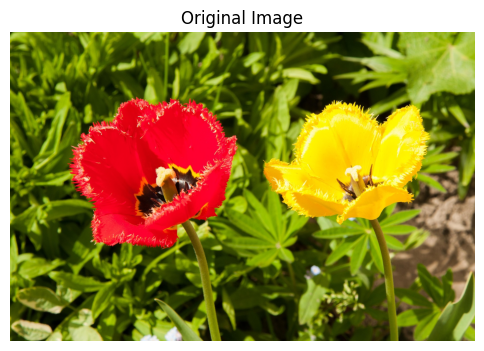

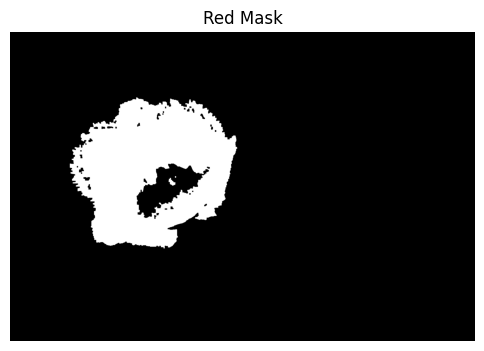

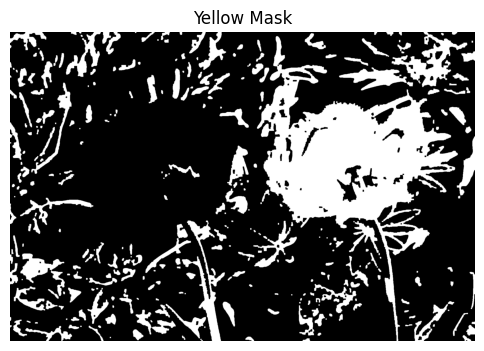

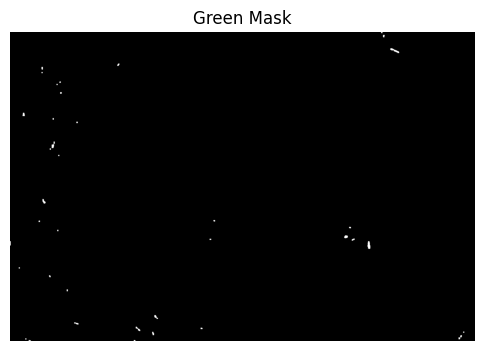

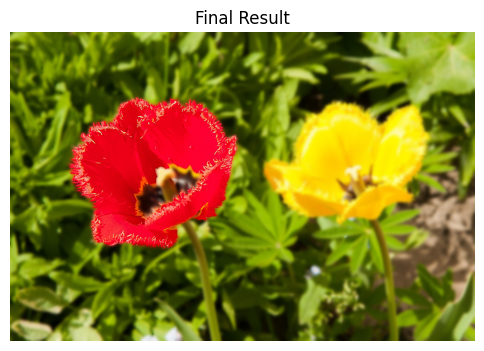

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Image I/O
# =========================
def load_image(path):
    img = cv2.imread("/content/task1test-2.jpg")
    if img is None:
        raise ValueError("Image not found")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_image(img, title="Image"):
    plt.figure(figsize=(6,6))
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


# =========================
# Color Space
# =========================
def to_hsv(image):
    return cv2.cvtColor(image, cv2.COLOR_RGB2HSV)


# =========================
# Masks
# =========================
def get_red_mask(hsv):
    lower1 = np.array([0, 120, 120])
    upper1 = np.array([10, 255, 255])

    lower2 = np.array([170, 120, 120])
    upper2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)

    return cv2.bitwise_or(mask1, mask2)


def get_yellow_mask(hsv):
    lower = np.array([20, 120, 120])
    upper = np.array([35, 255, 255])
    return cv2.inRange(hsv, lower, upper)


def get_green_mask(hsv):
    lower = np.array([40, 80, 80])
    upper = np.array([85, 255, 255])
    return cv2.inRange(hsv, lower, upper)


# =========================
# Mask Refinement
# =========================
def refine_mask(mask):
    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


# =========================
# Effects
# =========================
def apply_strong_sharpen(image):
    img = image.astype(np.float32)

    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=3)

    sharpened = cv2.addWeighted(img, 1.8, blurred, -0.8, 0)

    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_strong_blur(image):
    return cv2.GaussianBlur(image, (31, 31), 0)


# =========================
# Mask Utilities
# =========================
def apply_mask(image, mask):
    return cv2.bitwise_and(image, image, mask=mask)

def invert_mask(mask):
    return cv2.bitwise_not(mask)


# =========================
# Main Pipeline
# =========================
def selective_enhancement(image):
    hsv = to_hsv(image)

    # Masks
    red_mask = refine_mask(get_red_mask(hsv))
    yellow_mask = refine_mask(get_yellow_mask(hsv))
    green_mask = refine_mask(get_green_mask(hsv))

    # Effects
    sharpened = apply_strong_sharpen(image)
    blurred = apply_strong_blur(image)

    # Regions
    red_region = apply_mask(sharpened, red_mask)
    yellow_region = apply_mask(blurred, yellow_mask)
    green_region = apply_mask(image, green_mask)  # keep natural

    # Background (everything else blurred)
    combined_mask = cv2.bitwise_or(red_mask, yellow_mask)
    combined_mask = cv2.bitwise_or(combined_mask, green_mask)

    background_mask = invert_mask(combined_mask)
    background = apply_mask(blurred, background_mask)

    # Combine all
    result = cv2.add(red_region, yellow_region)
    result = cv2.add(result, green_region)
    result = cv2.add(result, background)

    return result, red_mask, yellow_mask, green_mask


# =========================
# Run
# =========================
if __name__ == "__main__":
    path = "flowers.jpg"  # <-- put your image here

    img = load_image(path)

    result, red_mask, yellow_mask, green_mask = selective_enhancement(img)

    show_image(img, "Original Image")
    show_image(red_mask, "Red Mask")
    show_image(yellow_mask, "Yellow Mask")
    show_image(green_mask, "Green Mask")
    show_image(result, "Final Result")